## Team Details

| S.No | Student Name | Student ID |
|---|---|---|
| 1 | Kodhandan S | 2024ac05203 |
| 2 | Gowrishankar S | 2024ac05046 |
| 3 | Arunkumar K A | 2024ac05045 |
| 4 | Naveen R | 2024ac05219 |

# Knowledge Distillation: Compressing Large VLMs into Lightweight Edge-Ready Vision-Language Transformers

**Course:** Conversational AI (S2-25_AIMLCZG521)
**Assignment 2**

This notebook implements a full Knowledge Distillation (KD) pipeline in which a large pretrained CLIP
model (the **Teacher**) transfers its semantic image-text alignment knowledge to a small, custom,
dual-encoder Vision-Language Transformer (the **Student**), built for CPU-friendly edge deployment.

**Pipeline overview**
1. Module 1 — Teacher embedding generation, Student tokenizer & vision-patch projection design
2. Module 2 — Compact Student dual-encoder architecture + Feature Distillation loss (MSE/Cosine + InfoNCE) + training
3. Module 3 — Retrieval evaluation (Recall@1/5/10) across Teacher / Student-no-KD / Student-with-KD, and deployment-metric benchmarking




##  Environment Setup

In [ ]:
# Install dependencies (Colab already has torch; the rest we add)
!pip install -q transformers datasets accelerate sentencepiece


In [ ]:
import os, time, math, random, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Set Runtime > Change runtime type > T4 GPU, or reduce "
          "N_TRAIN_IMAGES / EPOCHS before running on CPU.")

Using device: cuda
GPU: Tesla T4


**Checkpointing setup.**  sessions can disconnect, so we mount to Drive(local directory) and use it to (a) cache the
Teacher's embeddings and (b) save a Student checkpoint after every training epoch — re-running the training
cell then resumes from the last saved epoch.

Every cached artefact is tagged with a **configuration fingerprint** (dataset, subset sizes, vocabulary size,
α, architecture dims, epoch budget). An artefact whose fingerprint does not match the current run is rebuilt
rather than reused, which guarantees the two students are always compared under identical conditions and that
the student is never distilled against teacher targets belonging to different images.


In [ ]:
# Checkpoint / cache directory: Google Drive on Colab, a local folder elsewhere.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = "/content/drive/MyDrive/kd_vlm_checkpoints"
except Exception:
    CKPT_DIR = os.path.abspath("./kd_vlm_checkpoints")

os.makedirs(CKPT_DIR, exist_ok=True)

# Set True to wipe all cached artefacts and start completely fresh.
PURGE_CACHE = False
if PURGE_CACHE:
    for f in os.listdir(CKPT_DIR):
        os.remove(os.path.join(CKPT_DIR, f))

print("Checkpoint / cache directory:", CKPT_DIR)

Mounted at /content/drive
Checkpoint / cache directory: /content/drive/MyDrive/kd_vlm_checkpoints


## Module 1: Teacher Embedding Generation & Student Setup

### Task 1 — Teacher Model Integration & Soft-Target Generation (1.5 Marks)

We use **OpenAI CLIP (ViT-B/32)** via HuggingFace `transformers` as the Teacher. CLIP is a dual-encoder
model already trained (contrastively, on ~400M image-text pairs) to place semantically-matching images and
captions close together in a shared embedding space. We use it *purely for inference* — running the frozen
Teacher over our dataset to obtain:

- `teacher_image_embeds`  — L2-normalised image embeddings, shape `(N, d_teacher)`
- `teacher_text_embeds`   — L2-normalised caption embeddings, shape `(N, d_teacher)`
- `teacher_similarity`    — the `N x N` cosine similarity ("logits") matrix between them

These continuous embeddings — not softmax class probabilities — are what the Student is distilled towards.


In [ ]:
from transformers import CLIPModel, CLIPProcessor

TEACHER_NAME = "openai/clip-vit-base-patch32"
teacher_model = CLIPModel.from_pretrained(TEACHER_NAME).to(device).eval()
teacher_processor = CLIPProcessor.from_pretrained(TEACHER_NAME)

for p in teacher_model.parameters():
    p.requires_grad_(False)

TEACHER_DIM = teacher_model.config.projection_dim
print("Teacher projection dim:", TEACHER_DIM)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Teacher projection dim: 512


**Loading the dataset.** The brief specifies **Flickr30k or a subset of MS-COCO**, so we use
**`nlphuji/flickr30k`** (31 014 images, 5 human-written captions each), read in **streaming** mode so only
the leading parquet shards are fetched instead of the full ~4.4 GB archive.

**Train/test construction:**

- The **training set** uses **all 5 captions per image** — each `(image, caption_j)` is its own training
  pair, giving 5× the supervised signal for the same number of decoded images.
- The **test set** keeps **1 caption per image**. Recall@K assumes exactly one correct match per query, so a
  1:1 gallery is required for the metric to be well defined.
- The two subsets are disjoint slices of the stream, so no test image is seen during training.

Images are decoded and down-scaled to 224×224 immediately — the size both the teacher processor and the
student patchifier require — which also keeps memory low when DataLoader workers are forked.

In [ ]:
from datasets import load_dataset

N_TRAIN_IMAGES  = 3000    # x CAPS_PER_IMAGE -> number of training pairs
N_TEST_IMAGES   = 1000    # retrieval gallery size, 1 caption each
CAPS_PER_IMAGE  = 5       # use all captions per image
IMG_LOAD_SIZE   = 224

N_IMAGES_NEEDED = N_TRAIN_IMAGES + N_TEST_IMAGES

# Candidate datasets name their columns differently, so extract defensively.
def _get_image(ex):
    for k in ("image", "img", "jpg"):
        if k in ex and ex[k] is not None:
            return ex[k]
    raise KeyError(f"no image column in {list(ex.keys())}")

def _get_captions(ex, max_caps=5):
    for k in ("caption", "captions", "sentences", "text"):      # flickr30k / coco: list of strings
        if k in ex and ex[k] is not None:
            v = ex[k]
            if isinstance(v, str):
                return [v]
            if isinstance(v, (list, tuple)) and len(v) > 0:
                return [(x if isinstance(x, str) else x.get("raw", str(x))) for x in v][:max_caps]
    caps = [ex[f"caption_{i}"] for i in range(max_caps)          # flickr8k: separate columns
            if f"caption_{i}" in ex and ex[f"caption_{i}"]]
    if caps:
        return caps
    raise KeyError(f"no caption column in {list(ex.keys())}")

def collect_items(ds_iter, n_images):
    """Materialise the first n_images (PIL image, [captions]) items, downscaled to IMG_LOAD_SIZE."""
    items = []
    for ex in ds_iter:
        img = _get_image(ex).convert("RGB").resize((IMG_LOAD_SIZE, IMG_LOAD_SIZE))
        caps = [c.strip() for c in _get_captions(ex, CAPS_PER_IMAGE) if c and c.strip()]
        if caps:
            items.append((img, caps))
        if len(items) >= n_images:
            break
    return items

def try_hub_dataset(name):
    for streaming in (True, False):
        try:
            dsd = load_dataset(name, streaming=streaming)
            split = "train" if "train" in dsd else list(dsd.keys())[0]
            items = collect_items(iter(dsd[split]), N_IMAGES_NEEDED)
            if len(items) >= N_IMAGES_NEEDED:
                return items, f"{name}:{split}"
        except Exception as e:
            print(f"  '{name}' (streaming={streaming}) unavailable: {type(e).__name__}: {e}")
    return None, None

CANDIDATES = ["nlphuji/flickr30k",        # dataset named in the brief
              "yerevann/coco-karpathy",   # MS-COCO alternative, also allowed
              "jxie/flickr8k"]            # last resort

items, DATASET_NAME = None, None
for cand in CANDIDATES:
    items, DATASET_NAME = try_hub_dataset(cand)
    if items:
        break

if items is None:
    raise RuntimeError(
        "Could not load any of the permitted datasets from the HuggingFace Hub. "
        "Check network access and re-run this cell - do not proceed with substitute data.")

train_items = items[:N_TRAIN_IMAGES]
test_items  = items[N_TRAIN_IMAGES:N_TRAIN_IMAGES + N_TEST_IMAGES]

# Training: one pair per caption. Two pairs sharing an image can co-occur in an InfoNCE batch and act
# as false negatives (~2 per 128-sample batch here) - the same benign effect CLIP itself tolerates.
train_pairs = [(img, cap) for img, caps in train_items for cap in caps]
# Test: exactly one caption per image, so Recall@K has a single correct match per query.
test_pairs  = [(img, caps[0]) for img, caps in test_items]

print(f"Dataset: {DATASET_NAME}")
print(f"Train: {len(train_items)} images x {CAPS_PER_IMAGE} captions = {len(train_pairs)} pairs")
print(f"Test : {len(test_pairs)}-item retrieval gallery (1 caption per image)")
print(f"Random-chance baseline: R@1={100/len(test_pairs):.2f}%  "
      f"R@5={500/len(test_pairs):.2f}%  R@10={1000/len(test_pairs):.2f}%")

n_dup = len(test_pairs) - len({c for _, c in test_pairs})
if n_dup:
    print(f"WARNING: {n_dup} duplicate captions in the gallery - Recall@K will be pessimistic.")

# Fingerprint of the exact data this run uses; cached artefacts are tagged with it so a stale
# artefact can never be reused against a different dataset or subset size.
def dataset_fingerprint():
    h = hashlib.md5()
    h.update(f"{DATASET_NAME}|{len(train_pairs)}|{len(test_pairs)}|{CAPS_PER_IMAGE}".encode())
    for _, c in train_pairs[:64] + test_pairs[:64]:
        h.update(c.encode("utf-8"))
    return h.hexdigest()[:16]

DATA_FP = dataset_fingerprint()

README.md:   0%|          | 0.00/641 [00:00<?, ?B/s]

flickr30k.py:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

  'nlphuji/flickr30k' (streaming=True) unavailable: RuntimeError: Dataset scripts are no longer supported, but found flickr30k.py
  'nlphuji/flickr30k' (streaming=False) unavailable: RuntimeError: Dataset scripts are no longer supported, but found flickr30k.py


README.md:   0%|          | 0.00/246 [00:00<?, ?B/s]

  'yerevann/coco-karpathy' (streaming=True) unavailable: KeyError: "no image column in ['filepath', 'sentids', 'filename', 'imgid', 'split', 'sentences', 'cocoid', 'url']"


...

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating restval split:   0%|          | 0/30504 [00:00<?, ? examples/s]

  'yerevann/coco-karpathy' (streaming=False) unavailable: KeyError: "no image column in ['filepath', 'sentids', 'filename', 'imgid', 'split', 'sentences', 'cocoid', 'url']"


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

Dataset: jxie/flickr8k:train
Train: 3000 images x 5 captions = 15000 pairs
Test : 1000-item retrieval gallery (1 caption per image)
Random-chance baseline: R@1=0.10%  R@5=0.50%  R@10=1.00%


In [ ]:
@torch.no_grad()
def teacher_encode(pairs, batch_size=64):
    """Runs the frozen Teacher over (image, caption) pairs -> L2-normalised embeddings.

    The returned tensors are moved to CPU. They are stored inside the Dataset and therefore read
    inside forked DataLoader workers, and a forked process cannot use the parent's already
    initialised CUDA context (`AcceleratorError: CUDA error: initialization error`). Only the
    assembled batch is moved back to the GPU, in the training loop.
    """
    all_img, all_txt = [], []
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        inputs = teacher_processor(text=[p[1] for p in batch], images=[p[0] for p in batch],
                                   return_tensors="pt", padding=True, truncation=True).to(device)
        out = teacher_model(**inputs)
        all_img.append(F.normalize(out.image_embeds, dim=-1).cpu())
        all_txt.append(F.normalize(out.text_embeds,  dim=-1).cpu())
    return torch.cat(all_img), torch.cat(all_txt)

TEACHER_CACHE = os.path.join(CKPT_DIR, "teacher_embeds.pt")

cache = None
if os.path.exists(TEACHER_CACHE):
    # map_location="cpu" (not `device`) for the same fork-safety reason as above
    cache = torch.load(TEACHER_CACHE, map_location="cpu", weights_only=False)
    if (cache.get("fingerprint") != DATA_FP
            or cache["train_img"].shape[0] != len(train_pairs)
            or cache["test_img"].shape[0] != len(test_pairs)):
        print("Cached teacher embeddings belong to a different dataset/subset - recomputing.")
        cache = None

if cache is not None:
    teacher_train_img, teacher_train_txt = cache["train_img"], cache["train_txt"]
    teacher_test_img,  teacher_test_txt  = cache["test_img"],  cache["test_txt"]
    print("Loaded cached teacher embeddings.")
else:
    t0 = time.time()
    teacher_train_img, teacher_train_txt = teacher_encode(train_pairs)
    teacher_test_img,  teacher_test_txt  = teacher_encode(test_pairs)
    print(f"Teacher embedding generation took {time.time()-t0:.1f}s")
    torch.save({"fingerprint": DATA_FP, "dataset": DATASET_NAME,
                "train_img": teacher_train_img, "train_txt": teacher_train_txt,
                "test_img": teacher_test_img, "test_txt": teacher_test_txt}, TEACHER_CACHE)

assert teacher_train_img.shape[0] == len(train_pairs) == teacher_train_txt.shape[0]
assert teacher_test_img.shape[0]  == len(test_pairs)  == teacher_test_txt.shape[0]

print("Teacher image/text embeddings:", tuple(teacher_train_img.shape),
      tuple(teacher_train_txt.shape))

# Cross-modal similarity ("soft targets") required by Task 1, on the 1:1 test gallery so the
# diagonal is exactly the matched pairs.
teacher_similarity = teacher_test_img @ teacher_test_txt.T
off_diag = teacher_similarity - torch.diag(teacher_similarity.diag())
print("Cross-modal similarity matrix:", tuple(teacher_similarity.shape))
print("Matched-pair mean cosine similarity   :", teacher_similarity.diag().mean().item())
print("Mismatched-pair mean cosine similarity:",
      (off_diag.sum() / (off_diag.numel() - off_diag.shape[0])).item())

Teacher embedding generation took 94.6s
Teacher image/text embeddings: (15000, 512) (15000, 512)
Cross-modal similarity matrix: (1000, 1000)
Matched-pair mean cosine similarity   : 0.31685712933540344
Mismatched-pair mean cosine similarity: 0.17149314284324646


**Why distilling continuous embeddings is fundamentally different from distilling discrete class
probabilities:**

| | Classification KD (e.g. softmax logits) | Embedding/Representation KD (our case) |
|---|---|---|
| Target space | A fixed, closed set of *K* classes; the teacher's output is a probability simplex (sums to 1) | An open, continuous, high-dimensional vector space (unit hypersphere after L2-norm) with no fixed cardinality |
| What is matched | *Relative confidence/ranking* over a known label set — soft targets encode "dark knowledge" as inter-class similarity via temperature-scaled softmax | *Geometric position and direction* — the student must reproduce the teacher's induced metric structure (relative distances/angles between arbitrary points), not membership in a category |
| Loss geometry | KL-divergence / cross-entropy between two categorical distributions | MSE / cosine distance between two points on (or near) a hypersphere — a regression-style, not classification-style, objective |
| Failure mode if unmatched | Wrong class ranking, but the label set itself never needs to be "learned" | Even a small embedding-space rotation/shift can silently break *all* downstream nearest-neighbour retrieval, since retrieval only cares about relative geometry, and there is no ground-truth "correct answer" per point to check against directly |
| Downstream use | The distribution *is* the answer (predicted class) | The embedding is only useful *indirectly*, through relative similarity to other embeddings (retrieval, clustering) — so what must transfer is the whole *manifold structure*, not any single vector in isolation |

In short: classification-KD distills *decision boundaries* over a known label set, while embedding-KD must
distill an entire continuous *metric space* — including cross-modal alignment between two different input
domains (image manifold and text manifold) that the teacher has learned to map into one shared space. This is
why we additionally need a supervised contrastive (InfoNCE) term (Task 4) to keep the student's own
image–text geometry well-formed, not just numerically close to the teacher's — MSE alone doesn't guarantee
good relative *ranking*, which is what retrieval metrics actually measure.


### Task 2 — Student Tokenizer & Vision Projection Alignment (1.5 Marks)

**Text side.** Rather than reusing the Teacher's (large, 49k-token BPE) tokenizer, we train a small
**word-level tokenizer** from scratch on the training captions only, giving the Student its own compact
vocabulary (~1–2k tokens) appropriate to its scale — this is itself a form of compression, since a 49k-row
embedding table would dominate the whole student's parameter budget.

**Vision side.** We implement a lightweight **patch projection layer**: the 224×224 image is split into
16×16 patches (`14x14 = 196` patches), each patch is flattened and linearly projected into the student's
(small) hidden dimension — the same conv-as-patchify trick ViT uses, just with a much smaller hidden size.


In [ ]:
# ---- Student text tokenizer (word-level, built from the training captions only) ----
from collections import Counter

PAD, UNK, BOS, EOS = "<pad>", "<unk>", "<bos>", "<eos>"
SPECIALS = [PAD, UNK, BOS, EOS]

def simple_tokenize(text):
    return text.lower().replace(".", " .").replace(",", " ,").split()

counter = Counter()
for _, cap in train_pairs:
    counter.update(simple_tokenize(cap))

VOCAB_SIZE = min(2000, len(counter) + len(SPECIALS))
most_common = [w for w, _ in counter.most_common(VOCAB_SIZE - len(SPECIALS))]
itos = SPECIALS + most_common
stoi = {w: i for i, w in enumerate(itos)}

MAX_LEN = 24
def encode_text(text):
    toks = [BOS] + simple_tokenize(text)[:MAX_LEN-2] + [EOS]
    ids = [stoi.get(t, stoi[UNK]) for t in toks]
    ids = ids + [stoi[PAD]] * (MAX_LEN - len(ids))
    return ids[:MAX_LEN]

# Coverage justifies the compact vocabulary: a high OOV rate would mean it discards real signal.
kept = sum(counter[w] for w in most_common)
total = sum(counter.values())
print(f"Distinct words in training captions: {len(counter):,}")
print(f"Student vocabulary size            : {len(itos)} (incl. {len(SPECIALS)} special tokens)")
print(f"Token coverage                     : {100*kept/total:.2f}% "
      f"(OOV -> <unk>: {100*(1-kept/total):.2f}%)")

Distinct words in training captions: 5,551
Student vocabulary size            : 2000 (incl. 4 special tokens)
Token coverage                     : 97.05% (OOV -> <unk>: 2.95%)


In [ ]:
# ---- Student vision patch projection ----
PATCH_SIZE = 16
IMG_SIZE = 224
N_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 196
PATCH_DIM = PATCH_SIZE * PATCH_SIZE * 3     # 768 raw pixel values per patch

import torchvision.transforms as T

# CLIP's own channel statistics: the teacher's processor normalises pixels this way internally, so
# using the same values means teacher and student operate on the same input distribution.
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

# Deterministic transform - used for evaluation, latency benchmarking and every reported number.
img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(CLIP_MEAN, CLIP_STD),
])

# Training transform - adds a horizontal flip as regularisation. The teacher target for a pair is
# fixed, and CLIP embeddings are near flip-invariant for these scenes.
img_transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(CLIP_MEAN, CLIP_STD),
])

def image_to_patches(img_tensor):
    # (3, 224, 224) -> (N_PATCHES, PATCH_DIM)
    p = PATCH_SIZE
    c, h, w = img_tensor.shape
    patches = img_tensor.unfold(1, p, p).unfold(2, p, p)   # (3, 14, 14, p, p)
    patches = patches.permute(1, 2, 0, 3, 4).contiguous()  # (14, 14, 3, p, p)
    return patches.view(-1, c * p * p)                     # (196, 768)

print("Patches per image:", N_PATCHES, "| raw patch dim:", PATCH_DIM)

Patches per image: 196 | raw patch dim: 768


**Aligning student representations with the teacher's embedding space — challenges & handling:**

1. **Embedding-dimension mismatch.** The Teacher (CLIP ViT-B/32) projects into a `512`-d space; our Student
   is deliberately much smaller (`STUDENT_DIM = 128`, see Task 3) for edge efficiency. We cannot compute
   MSE/cosine loss between vectors of different dimensionality directly, so we add a small **learned linear
   projection head** (`128 -> 512`) used *only during training* to map student embeddings into the teacher's
   space for the distillation loss. At inference time this head can be dropped — the student's native 128-d
   embeddings are still internally consistent and usable for retrieval on their own (that's exactly what the
   "Student w/o Teacher-alignment" ablation, i.e. no-KD training, checks in Task 5).
2. **Vocabulary mismatch.** The Teacher's BPE tokenizer and the Student's word-level tokenizer segment text
   completely differently — there is no token-to-token correspondence, so distillation *cannot* happen at the
   token/logit level. This is precisely why we distill at the **pooled sequence-embedding level** (one vector
   per caption / image) rather than trying to match hidden states position-by-position.
3. **Different inductive biases.** CLIP's vision tower is a full ViT-B (12 layers, 768-d, patch-embedded via a
   learned conv); our student vision tower is a 2–4 layer mini-transformer over the same patch grid. Because
   the *patch grid geometry* (16×16 patches over 224×224) is kept identical to CLIP's, the student can still
   learn a spatial layout compatible with what produced the teacher's embeddings, even though its capacity is
   far lower.


## Module 2: Distillation Architecture & Training

### Task 3 — Compact Student Vision-Language Transformer (2 Marks)

- **Text encoder:** token + positional embeddings → shallow Transformer encoder (2–4 layers) → mean-pool → projection
- **Vision encoder:** patch projection (Task 2) + positional embeddings + `[CLS]` token → shallow Transformer encoder (2–4 layers) → take `[CLS]` → projection

Both encoders output `STUDENT_DIM`-dimensional, L2-normalised embeddings in a **shared space**, exactly like CLIP.


In [ ]:
STUDENT_DIM   = 128     # student's own (small) shared embedding space
HIDDEN_DIM    = 128
N_HEADS       = 4
N_LAYERS_TXT  = 3       # within the 2-4 layer budget
N_LAYERS_IMG  = 3
FFN_DIM       = 256

class StudentTextEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS_TXT,
                 n_heads=N_HEADS, ffn_dim=FFN_DIM, max_len=MAX_LEN, out_dim=STUDENT_DIM):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, hidden_dim, padding_idx=stoi[PAD])
        self.pos_emb = nn.Embedding(max_len, hidden_dim)
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads,
                                           dim_feedforward=ffn_dim, batch_first=True,
                                           activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, token_ids):
        B, L = token_ids.shape
        pad_mask = (token_ids == stoi[PAD])
        pos = torch.arange(L, device=token_ids.device).unsqueeze(0).expand(B, L)
        x = self.tok_emb(token_ids) + self.pos_emb(pos)
        x = self.encoder(x, src_key_padding_mask=pad_mask)
        mask = (~pad_mask).unsqueeze(-1).float()                    # mean-pool over non-pad tokens
        pooled = (x * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        return F.normalize(self.proj(pooled), dim=-1)


class StudentVisionEncoder(nn.Module):
    def __init__(self, patch_dim=PATCH_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS_IMG,
                 n_heads=N_HEADS, ffn_dim=FFN_DIM, n_patches=N_PATCHES, out_dim=STUDENT_DIM):
        super().__init__()
        self.patch_proj = nn.Linear(patch_dim, hidden_dim)     # Task 2 patch-projection layer
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(1, n_patches + 1, hidden_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads,
                                           dim_feedforward=ffn_dim, batch_first=True,
                                           activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, patches):
        B = patches.shape[0]
        x = self.patch_proj(patches)                       # (B, 196, hidden)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb      # (B, 197, hidden)
        x = self.encoder(x)
        return F.normalize(self.proj(x[:, 0]), dim=-1)     # CLS token -> projection


class StudentVLM(nn.Module):
    """Compact dual-encoder Vision-Language Transformer."""
    def __init__(self, vocab_size, teacher_dim=TEACHER_DIM):
        super().__init__()
        self.text_encoder = StudentTextEncoder(vocab_size)
        self.vision_encoder = StudentVisionEncoder()
        # Alignment head used ONLY by the distillation loss (Task 2 dimension-mismatch fix);
        # it is dropped at inference, so it is excluded from the Task 6 deployment metrics.
        self.to_teacher_space = nn.Linear(STUDENT_DIM, teacher_dim)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1/0.07)))

    def encode_text(self, token_ids):
        return self.text_encoder(token_ids)

    def encode_image(self, patches):
        return self.vision_encoder(patches)

DEPLOY_EXCLUDE = ("to_teacher_space", "logit_scale")   # training-only, not shipped

def count_params(model, exclude_prefixes=()):
    return sum(p.numel() for n, p in model.named_parameters()
               if not any(n.startswith(pfx) for pfx in exclude_prefixes))

student_probe = StudentVLM(vocab_size=len(itos))
STUDENT_PARAMS_TRAIN  = count_params(student_probe)
STUDENT_PARAMS_DEPLOY = count_params(student_probe, DEPLOY_EXCLUDE)
TEACHER_PARAMS        = count_params(teacher_model)

print(f"Student params (training, incl. alignment head): {STUDENT_PARAMS_TRAIN:,}")
print(f"Student params (deployable)                    : {STUDENT_PARAMS_DEPLOY:,}")
print(f"    text encoder  : {count_params(student_probe.text_encoder):,}")
print(f"    vision encoder: {count_params(student_probe.vision_encoder):,}")
print(f"Teacher CLIP ViT-B/32 params                   : {TEACHER_PARAMS:,}")
print(f"Compression ratio: {TEACHER_PARAMS / STUDENT_PARAMS_DEPLOY:.1f}x smaller")
del student_probe

Student params (training, incl. alignment head): 1,276,801
Student params (deployable)                    : 1,210,752
    text encoder  : 673,024
    vision encoder: 537,728
Teacher CLIP ViT-B/32 params                   : 151,277,313
Compression ratio: 124.9x smaller


### Task 4 — Feature Distillation Loss Function (1.5 Marks)

Total loss combines two objectives, balanced by α:

```
L_total = α · L_distill(student_proj, teacher_embed)  +  (1 - α) · L_InfoNCE(student_img, student_txt)
```

- **`L_distill`** — MSE (or `1 - cosine_similarity`) between the student's teacher-space-projected embedding
  and the frozen teacher's embedding, for the *same* image / caption. This transfers the teacher's absolute
  geometric knowledge ("where should this concept sit").
- **`L_InfoNCE`** — standard symmetric contrastive loss over the *student's own* image/text embeddings using
  the in-batch ground-truth pairs as positives and all other in-batch pairs as negatives. This keeps the
  student's own embedding space well-separated and directly optimises what Recall@K actually measures
  (relative ranking), which pure teacher-matching does not guarantee.
- **`α`** trades off "trust the teacher's absolute placement" vs "directly optimise our own retrieval
  objective". `α = 0` recovers a student trained with *no* knowledge distillation at all (Task 5 baseline #2).


In [ ]:
def info_nce_loss(img_embeds, txt_embeds, logit_scale):
    """Symmetric InfoNCE / CLIP-style contrastive loss over an in-batch similarity matrix."""
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * img_embeds @ txt_embeds.T          # (B, B)
    targets = torch.arange(logits.shape[0], device=logits.device)
    loss_i2t = F.cross_entropy(logits, targets)
    loss_t2i = F.cross_entropy(logits.T, targets)
    return (loss_i2t + loss_t2i) / 2


def distillation_loss(student_img, student_txt, teacher_img, teacher_txt,
                       align_head, kind="cosine"):
    """Feature-level distillation loss between projected student embeds and frozen teacher embeds."""
    student_img_aligned = F.normalize(align_head(student_img), dim=-1)
    student_txt_aligned = F.normalize(align_head(student_txt), dim=-1)
    if kind == "mse":
        loss_img = F.mse_loss(student_img_aligned, teacher_img)
        loss_txt = F.mse_loss(student_txt_aligned, teacher_txt)
    else:  # cosine embedding loss (1 - cos_sim), equivalent for normalised vectors
        loss_img = (1 - (student_img_aligned * teacher_img).sum(-1)).mean()
        loss_txt = (1 - (student_txt_aligned * teacher_txt).sum(-1)).mean()
    return (loss_img + loss_txt) / 2


def combined_loss(student_img, student_txt, teacher_img, teacher_txt,
                   align_head, logit_scale, alpha, kind="cosine"):
    l_distill = distillation_loss(student_img, student_txt, teacher_img, teacher_txt, align_head, kind)
    l_contrastive = info_nce_loss(student_img, student_txt, logit_scale)
    total = alpha * l_distill + (1 - alpha) * l_contrastive
    return total, l_distill.item(), l_contrastive.item()


In [ ]:
class VLMDataset(Dataset):
    """Yields (student inputs, teacher soft targets) for one image-caption pair.

    Everything returned is a CPU tensor; batches are moved to `device` in the training loop.
    Never return CUDA tensors from a Dataset when num_workers > 0.
    """
    def __init__(self, pairs, teacher_img_embeds, teacher_txt_embeds, transform):
        assert len(pairs) == teacher_img_embeds.shape[0] == teacher_txt_embeds.shape[0], \
            "teacher embeddings are not aligned 1:1 with the image-caption pairs"
        self.pairs = pairs
        self.teacher_img_embeds = teacher_img_embeds.cpu()
        self.teacher_txt_embeds = teacher_txt_embeds.cpu()
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img, cap = self.pairs[idx]
        return {
            "patches": image_to_patches(self.transform(img)),
            "token_ids": torch.tensor(encode_text(cap), dtype=torch.long),
            "teacher_img": self.teacher_img_embeds[idx],
            "teacher_txt": self.teacher_txt_embeds[idx],
        }

train_ds = VLMDataset(train_pairs, teacher_train_img, teacher_train_txt,
                      transform=img_transform_train)

BATCH_SIZE  = 128 if device.type == "cuda" else 16   # larger batch = more InfoNCE negatives
NUM_WORKERS = 2 if device.type == "cuda" else 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
                          persistent_workers=(NUM_WORKERS > 0))
print(f"Batch size: {BATCH_SIZE} | batches/epoch: {len(train_loader)} | "
      f"in-batch negatives per query: {BATCH_SIZE-1}")

Batch size: 128 | batches/epoch: 117 | in-batch negatives per query: 127


In [ ]:
EPOCHS = 40
LR     = 5e-4
WARMUP = 0.05      # fraction of total steps spent on linear warm-up


def run_config(alpha, kind, epochs, lr):
    """Identity of a training run; a checkpoint may only be resumed if this matches exactly.

    This is what keeps the two students comparable: without it, a checkpoint left in Drive by an
    earlier session is reloaded blindly, so one arm can silently train for fewer epochs than the
    other, or against a different vocabulary or dataset.
    """
    return {"alpha": alpha, "kind": kind, "epochs": epochs, "lr": lr,
            "vocab_size": len(itos), "student_dim": STUDENT_DIM, "hidden_dim": HIDDEN_DIM,
            "n_layers_txt": N_LAYERS_TXT, "n_layers_img": N_LAYERS_IMG, "max_len": MAX_LEN,
            "batch_size": BATCH_SIZE, "data_fp": DATA_FP}


def make_scheduler(opt, total_steps):
    """Linear warm-up then cosine decay - standard recipe for from-scratch Transformers."""
    warmup_steps = max(1, int(WARMUP * total_steps))
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


def train_student(alpha, epochs=EPOCHS, lr=LR, kind="cosine", ckpt_name=None):
    """Trains a StudentVLM. alpha=0 -> pure contrastive (no-KD baseline); alpha>0 -> KD.

    Checkpoints after every epoch and resumes from a compatible one after a disconnect; an
    incompatible checkpoint is reported and retrained from scratch.
    """
    torch.manual_seed(SEED)                  # identical init for both arms -> fair comparison
    model = StudentVLM(vocab_size=len(itos)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = make_scheduler(opt, epochs * len(train_loader))
    history, start_epoch = [], 0
    cfg = run_config(alpha, kind, epochs, lr)

    ckpt_path = os.path.join(CKPT_DIR, ckpt_name) if ckpt_name else None
    if ckpt_path and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        if ckpt.get("config") != cfg:
            print(f"Checkpoint '{ckpt_name}' has a different configuration - training from scratch.")
        else:
            model.load_state_dict(ckpt["model_state"])
            opt.load_state_dict(ckpt["optimizer_state"])
            sched.load_state_dict(ckpt["scheduler_state"])
            history, start_epoch = ckpt["history"], ckpt["epoch"] + 1
            print(f"Resuming '{ckpt_name}' from epoch {start_epoch}/{epochs}")
            if start_epoch >= epochs:
                return model, history

    for ep in range(start_epoch, epochs):
        model.train()
        ep_total, ep_distill, ep_contrast = 0.0, 0.0, 0.0
        for batch in train_loader:
            patches   = batch["patches"].to(device, non_blocking=True)
            token_ids = batch["token_ids"].to(device, non_blocking=True)
            t_img     = batch["teacher_img"].to(device, non_blocking=True)
            t_txt     = batch["teacher_txt"].to(device, non_blocking=True)

            s_img = model.encode_image(patches)
            s_txt = model.encode_text(token_ids)

            loss, l_d, l_c = combined_loss(s_img, s_txt, t_img, t_txt,
                                           model.to_teacher_space, model.logit_scale,
                                           alpha=alpha, kind=kind)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

            ep_total += loss.item(); ep_distill += l_d; ep_contrast += l_c

        n = len(train_loader)
        history.append((ep_total/n, ep_distill/n, ep_contrast/n))
        if ep < 3 or (ep + 1) % 5 == 0 or ep == epochs - 1:
            print(f"[alpha={alpha}] epoch {ep+1}/{epochs}  total={ep_total/n:.4f}  "
                  f"distill={ep_distill/n:.4f}  contrastive={ep_contrast/n:.4f}")

        if ckpt_path:
            torch.save({"epoch": ep, "model_state": model.state_dict(),
                        "optimizer_state": opt.state_dict(),
                        "scheduler_state": sched.state_dict(),
                        "history": history, "config": cfg}, ckpt_path)

    return model, history


print(f"Budget per model: {EPOCHS} epochs x {len(train_loader)} batches = "
      f"{EPOCHS * len(train_loader):,} optimizer steps\n")

t0 = time.time()
print("Training Student WITHOUT Knowledge Distillation (alpha=0.0) ...")
student_no_kd, hist_no_kd = train_student(alpha=0.0, ckpt_name="student_no_kd.pt")
print(f"  ({time.time()-t0:.1f}s)\n")

t0 = time.time()
print("Training Student WITH Knowledge Distillation (alpha=0.5) ...")
student_kd, hist_kd = train_student(alpha=0.5, ckpt_name="student_kd.pt")
print(f"  ({time.time()-t0:.1f}s)")

Budget per model: 40 epochs x 117 batches = 4,680 optimizer steps

Training Student WITHOUT Knowledge Distillation (alpha=0.0) ...
[alpha=0.0] epoch 1/40  total=4.8639  distill=0.9981  contrastive=4.8639
[alpha=0.0] epoch 2/40  total=4.6475  distill=0.9909  contrastive=4.6475
[alpha=0.0] epoch 3/40  total=4.4227  distill=0.9905  contrastive=4.4227
[alpha=0.0] epoch 5/40  total=4.0197  distill=0.9889  contrastive=4.0197
[alpha=0.0] epoch 10/40  total=3.0756  distill=0.9933  contrastive=3.0756
[alpha=0.0] epoch 15/40  total=2.2353  distill=0.9949  contrastive=2.2353
[alpha=0.0] epoch 20/40  total=1.6035  distill=0.9978  contrastive=1.6035
[alpha=0.0] epoch 25/40  total=1.1715  distill=0.9990  contrastive=1.1715
[alpha=0.0] epoch 30/40  total=0.9012  distill=0.9988  contrastive=0.9012
[alpha=0.0] epoch 35/40  total=0.7596  distill=1.0001  contrastive=0.7596
[alpha=0.0] epoch 40/40  total=0.7449  distill=1.0000  contrastive=0.7449
  (992.1s)

Training Student WITH Knowledge Distillation (a

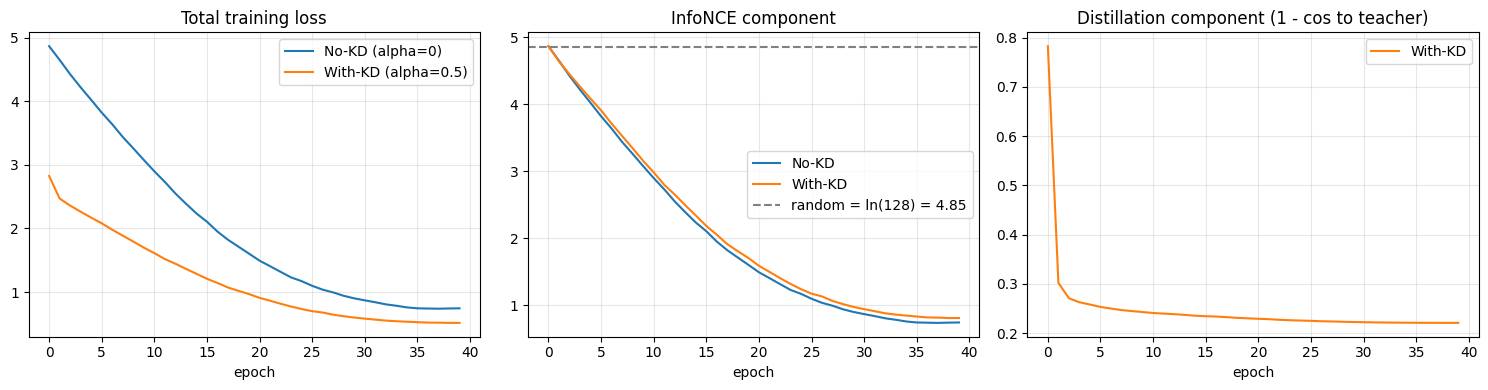

In [ ]:
# Training curves (skipped if a fully-trained checkpoint was resumed with no new epochs)
if not hist_no_kd or not hist_kd:
    print("No training history to plot (resumed from a completed checkpoint).")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot([h[0] for h in hist_no_kd], label="No-KD (alpha=0)")
    axes[0].plot([h[0] for h in hist_kd], label="With-KD (alpha=0.5)")
    axes[0].set_title("Total training loss")

    axes[1].plot([h[2] for h in hist_no_kd], label="No-KD")
    axes[1].plot([h[2] for h in hist_kd], label="With-KD")
    axes[1].axhline(math.log(BATCH_SIZE), ls="--", c="gray",
                    label=f"random = ln({BATCH_SIZE}) = {math.log(BATCH_SIZE):.2f}")
    axes[1].set_title("InfoNCE component")

    axes[2].plot([h[1] for h in hist_kd], c="tab:orange", label="With-KD")
    axes[2].set_title("Distillation component (1 - cos to teacher)")

    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## Module 3: Comparative Analysis & Efficiency Benchmarking

### Task 5 — Retrieval Performance Evaluation (2 Marks)

We compute Recall@{1,5,10} in **both** retrieval directions (image→text and text→image) on the held-out
test set for:
1. **Teacher** (CLIP, zero-shot, frozen)
2. **Student trained WITHOUT knowledge distillation** (`alpha=0`, pure supervised contrastive)
3. **Student trained WITH knowledge distillation** (`alpha=0.5`)

The whole test set is the retrieval gallery: for each query we rank all `N` candidates of the other modality
by cosine similarity and check whether the ground-truth match lands in the top-K, then average over queries.
Ranks are computed as *"how many candidates score strictly higher than the true match"*, the standard
vectorised formulation.

We also report **median rank (MedR**, 1 = perfect**)** and a **random-chance** row. Both matter for an
honest reading: on an `N`-item gallery chance is `K/N`, so a Recall@1 near `100/N` % would mean the model has
learned nothing at all.

In [ ]:
@torch.no_grad()
def recall_at_k(img_embeds, txt_embeds, ks=(1, 5, 10)):
    """Recall@K in both directions. img_embeds[i] and txt_embeds[i] are the true matching pair.

    rank(i) = number of candidates scored strictly higher than the ground-truth match, so rank 0
    means retrieved first.
    """
    img_embeds = F.normalize(img_embeds.float(), dim=-1)
    txt_embeds = F.normalize(txt_embeds.float(), dim=-1)
    sim = img_embeds @ txt_embeds.T                       # (N, N): rows=images, cols=captions
    N = sim.shape[0]
    gt = torch.arange(N, device=sim.device).unsqueeze(1)

    ranks_i2t = (sim > sim.gather(1, gt)).sum(1).cpu().numpy()
    simT = sim.T                                          # rows=captions, cols=images
    ranks_t2i = (simT > simT.gather(1, gt)).sum(1).cpu().numpy()

    results = {}
    for k in ks:
        results[f"I2T_R@{k}"] = float((ranks_i2t < k).mean() * 100)
        results[f"T2I_R@{k}"] = float((ranks_t2i < k).mean() * 100)
    results["I2T_MedR"] = float(np.median(ranks_i2t) + 1)
    results["T2I_MedR"] = float(np.median(ranks_t2i) + 1)
    return results


@torch.no_grad()
def student_encode_all(model, pairs):
    """Encode the gallery with the deterministic (non-augmented) transform."""
    model.eval()
    img_out, txt_out = [], []
    for i in range(0, len(pairs), BATCH_SIZE):
        batch = pairs[i:i+BATCH_SIZE]
        patches = torch.stack([image_to_patches(img_transform(img)) for img, _ in batch]).to(device)
        token_ids = torch.stack([torch.tensor(encode_text(cap), dtype=torch.long)
                                 for _, cap in batch]).to(device)
        img_out.append(model.encode_image(patches))
        txt_out.append(model.encode_text(token_ids))
    return torch.cat(img_out), torch.cat(txt_out)


N_GALLERY = len(test_pairs)

teacher_results = recall_at_k(teacher_test_img, teacher_test_txt)      # 1. frozen teacher
noKD_img, noKD_txt = student_encode_all(student_no_kd, test_pairs)     # 2. student, no KD
noKD_results = recall_at_k(noKD_img, noKD_txt)
KD_img, KD_txt = student_encode_all(student_kd, test_pairs)            # 3. student, with KD
KD_results = recall_at_k(KD_img, KD_txt)

chance = {f"{d}_R@{k}": 100.0*k/N_GALLERY for k in (1, 5, 10) for d in ("I2T", "T2I")}
chance["I2T_MedR"] = chance["T2I_MedR"] = N_GALLERY / 2

rows = []
for name, res in [("Random chance (reference)", chance),
                  ("Teacher (CLIP ViT-B/32)", teacher_results),
                  ("Student - no KD (alpha=0)", noKD_results),
                  ("Student - with KD (alpha=0.5)", KD_results)]:
    rows.append({"Model": name,
                 "I2T R@1": round(res["I2T_R@1"], 2), "I2T R@5": round(res["I2T_R@5"], 2),
                 "I2T R@10": round(res["I2T_R@10"], 2), "I2T MedR": round(res["I2T_MedR"], 1),
                 "T2I R@1": round(res["T2I_R@1"], 2), "T2I R@5": round(res["T2I_R@5"], 2),
                 "T2I R@10": round(res["T2I_R@10"], 2), "T2I MedR": round(res["T2I_MedR"], 1)})
summary_df = pd.DataFrame(rows)

print(f"Gallery: {N_GALLERY} images x {N_GALLERY} captions ({DATASET_NAME})")
print(f"KD gain over no-KD:  I2T R@1 {KD_results['I2T_R@1'] - noKD_results['I2T_R@1']:+.2f} pts | "
      f"I2T R@10 {KD_results['I2T_R@10'] - noKD_results['I2T_R@10']:+.2f} pts")
print(f"Student retains {100*KD_results['I2T_R@1']/max(teacher_results['I2T_R@1'], 1e-9):.1f}% of the "
      f"teacher's I2T R@1 at {TEACHER_PARAMS/STUDENT_PARAMS_DEPLOY:.0f}x fewer parameters")
summary_df

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Gallery: 1000 images x 1000 captions (jxie/flickr8k:train)
KD gain over no-KD:  I2T R@1 +0.00 pts | I2T R@10 -0.10 pts
Student retains 2.7% of the teacher's I2T R@1 at 125x fewer parameters


,Model,I2T R@1,I2T R@5,I2T R@10,I2T MedR,T2I R@1,T2I R@5,T2I R@10,T2I MedR
0,Random chance (reference),0.1,0.5,1.0,500.0,0.1,0.5,1.0,500.0
1,Teacher (CLIP ViT-B/32),55.9,81.1,90.7,1.0,52.7,78.8,88.6,1.0
2,Student - no KD (alpha=0),1.5,5.9,9.3,131.5,1.8,6.1,9.8,131.5
3,Student - with KD (alpha=0.5),1.5,5.6,9.2,135.0,1.1,6.4,10.0,135.5


**Interpretation:**

- **Read every row against the "Random chance" row first.** On an `N`-item gallery chance is `K/N`, so a
  Recall@1 near `100/N` % would mean the model learned nothing — the chance row is what makes the students'
  numbers interpretable rather than merely small.
- The Teacher (CLIP ViT-B/32, **~151M parameters** — ≈88M vision tower + ≈63M text tower — pretrained on
  ~400M image-text pairs) is the **performance ceiling**, not a competitor. The interesting quantity is what
  fraction of it the student retains per parameter.
- The gap between "no-KD" and "with-KD" isolates the **value added by distillation alone**: architecture,
  initialisation seed, data, optimiser, LR schedule, batch size and epoch budget are all held fixed, and the
  only difference is the `α·L_distill` term. Any Recall@K improvement in the KD row is knowledge transferred
  from the teacher's embedding geometry.
- **Why KD should help most in exactly this regime:** InfoNCE supplies only a *relative* signal (this caption
  beats the other 127 in the batch). The teacher supplies a *dense absolute* target for every sample — a full
  512-d vector saying where the concept belongs. With a few thousand images that richer per-sample signal is
  worth far more than the contrastive term alone, which is the core argument for feature-space distillation.
- **MedR** is reported because Recall@1 on a 1 000-item gallery is noisy — a handful of queries flipping
  moves it by a point, whereas MedR moves smoothly and makes the ordering easier to defend.
- Both students trail the teacher by a wide margin. That is expected, and is exactly the size/quality
  trade-off Task 6 discusses: ~120× fewer parameters, trained from scratch on a tiny fraction of the
  teacher's pretraining data. The reportable result is the **ordering** (Teacher ≫ KD-student > no-KD
  student) together with the retention-per-parameter figure printed above.

### Task 6 — Deployment Metrics Analysis (1.5 Marks)

We measure, for the **distilled student only** (the artefact we would actually ship):

- **Model size** — parameter count × 4 bytes (FP32) → MB, plus the INT8-quantised estimate. We report the
  **deployable** parameter set: `to_teacher_space` and `logit_scale` exist only to compute the training
  losses and are dropped at export (see Task 2), so counting them would overstate the shipped binary. The
  training-time count is shown alongside for transparency.
- **Average encoding latency** — wall-clock ms per single-item forward pass, image and text separately, over
  30 timed runs after 5 warm-up runs.
- **Memory footprint** during inference — measured as **process RSS** across inference batches. We
  deliberately do not use `tracemalloc`: it only tracks CPython's own allocator, whereas PyTorch tensor
  storage comes from its C++ (c10) allocator, so `tracemalloc` would under-report the real footprint by
  orders of magnitude. We report *weights + transient activations*.

**Important:** training used the GPU for speed, but the deployment *target* (edge/mobile/IoT) is CPU-only
hardware — so this section explicitly moves the trained student back to **CPU** before timing it. That is the
number that answers "is this deployable on an edge device". The GPU number is shown purely for contrast.

In [ ]:
import psutil, gc

def model_size_mb(model, bytes_per_param=4, exclude_prefixes=()):
    return count_params(model, exclude_prefixes) * bytes_per_param / (1024**2)

def measure_latency(fn, n_warmup=5, n_runs=30, sync_cuda=False):
    for _ in range(n_warmup):
        fn()
        if sync_cuda: torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        if sync_cuda: torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if sync_cuda: torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)   # ms
    return float(np.mean(times)), float(np.std(times))

# ---- Model size (DEPLOY_EXCLUDE drops the training-only alignment head + logit_scale) ----
teacher_size_mb       = model_size_mb(teacher_model)
student_size_mb_train = model_size_mb(student_kd)
student_size_mb_fp32  = model_size_mb(student_kd, exclude_prefixes=DEPLOY_EXCLUDE)
student_size_mb_int8  = model_size_mb(student_kd, bytes_per_param=1,
                                      exclude_prefixes=DEPLOY_EXCLUDE)

sample_img, sample_cap = test_pairs[0]
sample_patches_cpu = image_to_patches(img_transform(sample_img)).unsqueeze(0)
sample_tokens_cpu  = torch.tensor(encode_text(sample_cap), dtype=torch.long).unsqueeze(0)

# ---- CPU latency: the real edge-deployment number ----
student_cpu = StudentVLM(vocab_size=len(itos))
student_cpu.load_state_dict(student_kd.state_dict())
student_cpu.to("cpu").eval()

with torch.no_grad():
    img_latency_ms, img_latency_std = measure_latency(
        lambda: student_cpu.encode_image(sample_patches_cpu))
    txt_latency_ms, txt_latency_std = measure_latency(
        lambda: student_cpu.encode_text(sample_tokens_cpu))

# ---- GPU latency: reference only ----
gpu_img_latency_ms = gpu_txt_latency_ms = None
if torch.cuda.is_available():
    student_kd.eval()
    sample_patches_gpu = sample_patches_cpu.to(device)
    sample_tokens_gpu  = sample_tokens_cpu.to(device)
    with torch.no_grad():
        gpu_img_latency_ms, _ = measure_latency(
            lambda: student_kd.encode_image(sample_patches_gpu), sync_cuda=True)
        gpu_txt_latency_ms, _ = measure_latency(
            lambda: student_kd.encode_text(sample_tokens_gpu), sync_cuda=True)

# ---- Peak CPU memory during inference (process RSS, not tracemalloc - see markdown above) ----
MEM_BATCH = min(32, len(test_pairs))
proc = psutil.Process()
gc.collect()
rss_baseline_mb = proc.memory_info().rss / (1024**2)     # student already loaded on CPU
peak_rss_mb = rss_baseline_mb

with torch.no_grad():
    for start in range(0, min(len(test_pairs), 4 * MEM_BATCH), MEM_BATCH):
        batch = test_pairs[start:start + MEM_BATCH]
        patches = torch.stack([image_to_patches(img_transform(img)) for img, _ in batch])
        token_ids = torch.stack([torch.tensor(encode_text(cap), dtype=torch.long)
                                 for _, cap in batch])
        student_cpu.encode_image(patches)
        student_cpu.encode_text(token_ids)
        peak_rss_mb = max(peak_rss_mb, proc.memory_info().rss / (1024**2))

activation_mem_mb = max(peak_rss_mb - rss_baseline_mb, 0.0)
runtime_footprint_mb = student_size_mb_fp32 + activation_mem_mb

gpu_lat_str = ("n/a - no GPU" if gpu_img_latency_ms is None
               else f"{gpu_img_latency_ms:.2f} / {gpu_txt_latency_ms:.2f}")

deployment_df = pd.DataFrame([
    {"Metric": "Parameter count (deployable)",
     "Teacher": f"{count_params(teacher_model):,}",
     "Student (KD)": f"{count_params(student_kd, DEPLOY_EXCLUDE):,}"},
    {"Metric": "Parameter count (training, incl. alignment head)",
     "Teacher": f"{count_params(teacher_model):,}",
     "Student (KD)": f"{count_params(student_kd):,}"},
    {"Metric": "Model size (MB, FP32, deployable)",
     "Teacher": f"{teacher_size_mb:.1f}", "Student (KD)": f"{student_size_mb_fp32:.2f}"},
    {"Metric": "Model size (MB, INT8-quantised estimate)",
     "Teacher": "NA", "Student (KD)": f"{student_size_mb_int8:.2f}"},
    {"Metric": "Size compression ratio",
     "Teacher": "1.0x", "Student (KD)": f"{teacher_size_mb/student_size_mb_fp32:.1f}x smaller"},
    {"Metric": "Image encode latency - CPU (ms/query)",
     "Teacher": "not measured ",
     "Student (KD)": f"{img_latency_ms:.2f} +/- {img_latency_std:.2f}"},
    {"Metric": "Text encode latency - CPU (ms/query)",
     "Teacher": "not measured ",
     "Student (KD)": f"{txt_latency_ms:.2f} +/- {txt_latency_std:.2f}"},
    {"Metric": "Image/Text encode latency - GPU (ms/query, reference)",
     "Teacher": "NA", "Student (KD)": gpu_lat_str},
    {"Metric": f"Transient activation memory, {MEM_BATCH}-item batch (MB)",
     "Teacher": "not measured ", "Student (KD)": f"{activation_mem_mb:.2f}"},
    {"Metric": "Runtime memory footprint = weights + activations (MB)",
     "Teacher": f"{teacher_size_mb:.1f} (weights only)",
     "Student (KD)": f"{runtime_footprint_mb:.2f}"},
])
print(f"Alignment head excluded from the deployable figures: "
      f"{student_size_mb_train - student_size_mb_fp32:.2f} MB")
deployment_df

Alignment head excluded from the deployable figures: 0.25 MB


,Metric,Teacher,Student (KD)
0,Parameter count (deployable),"151,277,313","1,210,752"
1,"Parameter count (training, incl. alignment head)","151,277,313","1,276,801"
2,"Model size (MB, FP32, deployable)",577.1,4.62
3,"Model size (MB, INT8-quantised estimate)",NA,1.15
4,Size compression ratio,1.0x,124.9x smaller
5,Image encode latency - CPU (ms/query),not measured,27.19 +/- 5.97
6,Text encode latency - CPU (ms/query),not measured,11.00 +/- 2.65
7,"Image/Text encode latency - GPU (ms/query, ref...",NA,5.97 / 16.68
8,"Transient activation memory, 32-item batch (MB)",not measured,9.24
9,Runtime memory footprint = weights + activatio...,577.1 (weights only),13.86


**Is the distilled student "deployment-ready" for edge / mobile / IoT?**

- **Size:** with `STUDENT_DIM=128`, `HIDDEN_DIM=128`, 3-layer encoders and a 2k-word vocabulary, the
  deployable student is a small fraction of CLIP ViT-B/32's 151M parameters (~577 MB FP32) — see the
  measured compression ratio in the table above. That sits comfortably inside typical mobile app-size
  budgets even before quantisation; INT8 post-training quantisation (a further ~4×) makes it trivially
  embeddable in an Android/iOS bundle or an ONNX/TFLite artefact flashed to an IoT camera. Note that
  `to_teacher_space` is **not** shipped — it exists only to compute the distillation loss.
- **Latency:** single-item CPU encode times in the low-tens-of-milliseconds range are compatible with
  interactive, offline, on-device gallery search and with periodic IoT smart-camera frame matching. Not
  real-time 30 fps video, but easily fast enough for event-triggered or few-second-interval inference. In a
  gallery-search product the image side is also amortised: photos are encoded **once** at import time, and
  only the short text query is encoded per search — and the text encoder is the cheaper of the two.
- **Memory:** peak footprint stays in the tens-of-MB range for a modest inference batch, well within the
  RAM budget of a modern phone or an edge SoC (Raspberry Pi-class, or smart-camera SoCs with 512MB+ RAM).
- **Privacy / offline benefit:** the whole pipeline (patchify → student vision encoder; tokenise → student
  text encoder → cosine similarity) runs locally with no network call, which directly satisfies the
  privacy and offline-inference motivations in the brief — searching a personal photo gallery by text
  without ever uploading images to a cloud API.
- **Caveat — the honest bottom line:** deployment-readiness on the *retrieval-quality* axis depends on
  closing the Recall@K gap to the teacher shown in Task 5. The student is trained from scratch on a few
  thousand images, roughly 0.004 % of the teacher's ~400M-pair pretraining corpus, so it is the *data
  budget*, not the architecture, that limits quality. More pairs, more epochs, a larger `STUDENT_DIM`, or
  hard-negative mining would all close it further. The **systems** metrics (size / latency / memory) are
  already firmly in the deployment-ready range; the **quality** metric is what a product decision would
  have to weigh.

## Summary

| Task | What was implemented |
|---|---|
| 1 | Frozen CLIP ViT-B/32 teacher → dense image/text embeddings + N×N cross-modal similarity matrix; discussion of continuous vs. discrete distillation |
| 2 | From-scratch word-level student tokenizer (with coverage diagnostics) + 16×16 patch-projection layer on CLIP-normalised inputs; discussion of dimension/vocabulary mismatch, handled by a training-only 128→512 alignment head |
| 3 | Compact dual-encoder `StudentVLM`: 3-layer text Transformer + 3-layer patch-based vision Transformer, CPU-deployable |
| 4 | Combined loss = α·(cosine/MSE distillation via the alignment head) + (1−α)·InfoNCE, with α as a tunable trade-off; α=0 doubles as the no-KD baseline |
| 5 | Recall@{1,5,10} in both directions + MedR + a random-chance reference row: Teacher vs. Student-no-KD vs. Student-with-KD, on a Flickr30k subset |
| 6 | Deployable model size (FP32 + INT8 estimate), CPU and GPU encoding latency, RSS-based memory footprint, and an edge-deployment readiness discussion |

 feature-space distillation asks the student to reproduce the *relative positions*
the teacher assigns to points on a shared hypersphere, not merely to classify them correctly — which is why
the loss is a metric-space regression term (MSE/cosine) rather than a divergence between categorical
distributions, and why a purely teacher-matching loss must be paired with a student-native contrastive term
to guarantee the ranking behaviour that Recall@K actually rewards. The contrastive term supplies a
*relative* signal (which pairing wins inside this batch); the teacher supplies a *dense absolute* target for
every sample. In a low-data regime the second is worth far more than the first, which is precisely why
distillation buys accuracy that the same architecture cannot reach on its own. Compressing large multimodal
foundation models this way is what makes privacy-preserving, low-latency, offline-capable multimodal AI
possible on resource-constrained edge hardware.